24BAD010-Anusri T
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


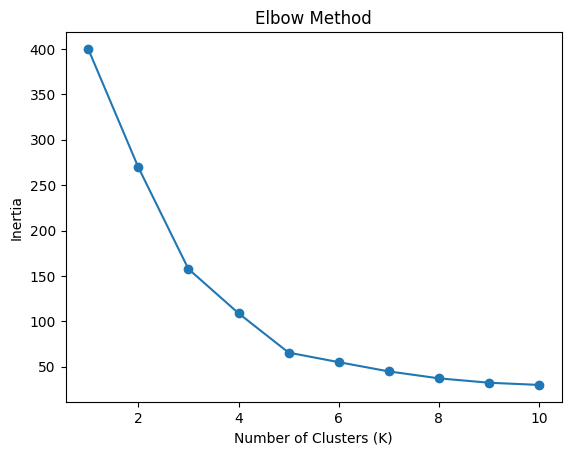

Silhouette Score: 0.5546571631111091


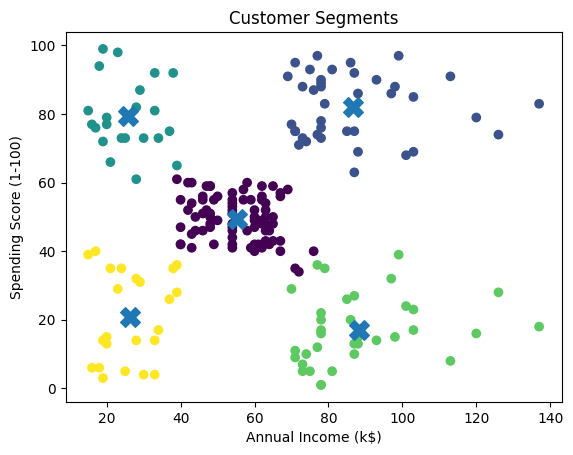

         Annual Income (k$)  Spending Score (1-100)        Age
Cluster                                                       
0                 55.296296               49.518519  42.716049
1                 86.538462               82.128205  32.692308
2                 25.727273               79.363636  25.272727
3                 88.200000               17.114286  41.114286
4                 26.304348               20.913043  45.217391


In [1]:
print("24BAD010-Anusri T")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv(r"C:\Users\anusr\Downloads\Mall_Customers.csv")

print(df.head())
print(df.info())

df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)
plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()
print(cluster_summary)

24BAD010-Anusri T


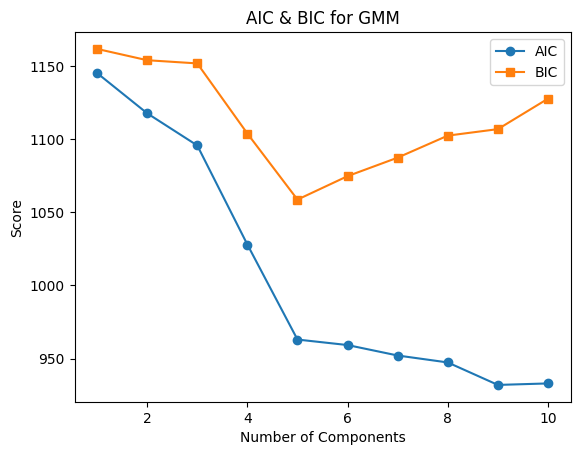


Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245

Cluster Probability Distribution (first 5 rows):
   Cluster_1_Prob  Cluster_2_Prob  Cluster_3_Prob  Cluster_4_Prob  \
0    1.576897e-05    1.880092e-08    9.520312e-04    5.200131e-08   
1    1.627762e-05    1.895968e-04    9.997902e-01    4.210134e-23   
2    2.213394e-19    9.526157e-19    1.225495e-12    1.862233e-04   
3    1.054448e-04    1.800877e-04    9.996937e-01    3.793901e-21   
4    6.473014e-05    3.842732e-08    1.556695e-03    4.757227e-08   

   Cluster_5_Prob  
0        0.999032  
1        0.000004  
2        0.999814  
3        0.000021  
4        0.998378  

Average Cluster Probabilities:
Cluster_1_Prob    0.413649
Cluster_2_Prob    0.196718
Cluster_3_Prob    0.103331
Cluster_4_Prob    0.164785
Cluster_5_Prob    0.121517
dtype: float64


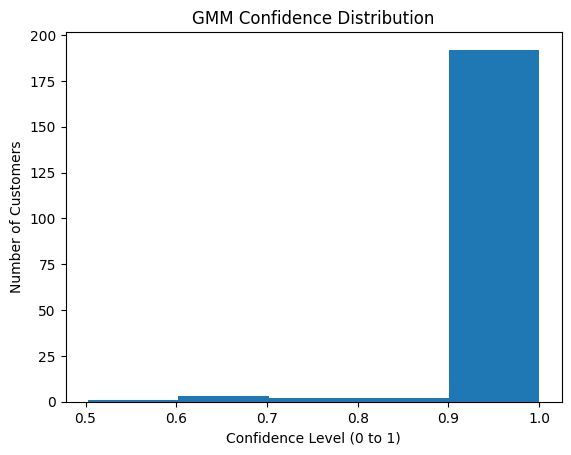


Average Confidence Level: 0.9826598124330809


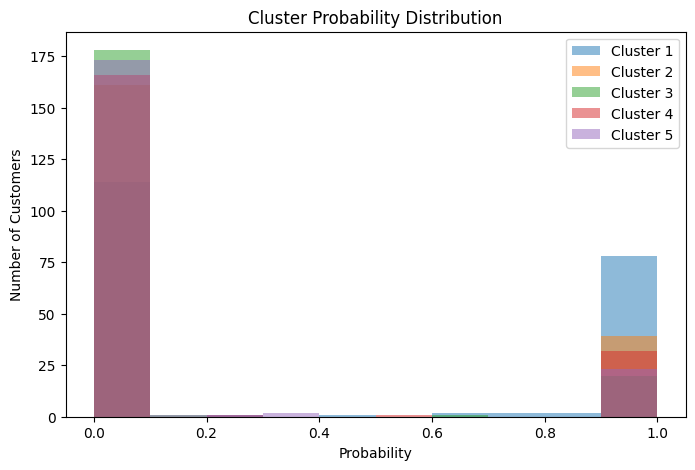

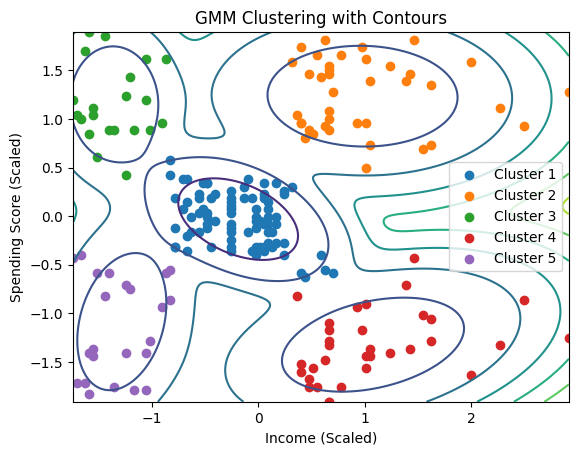

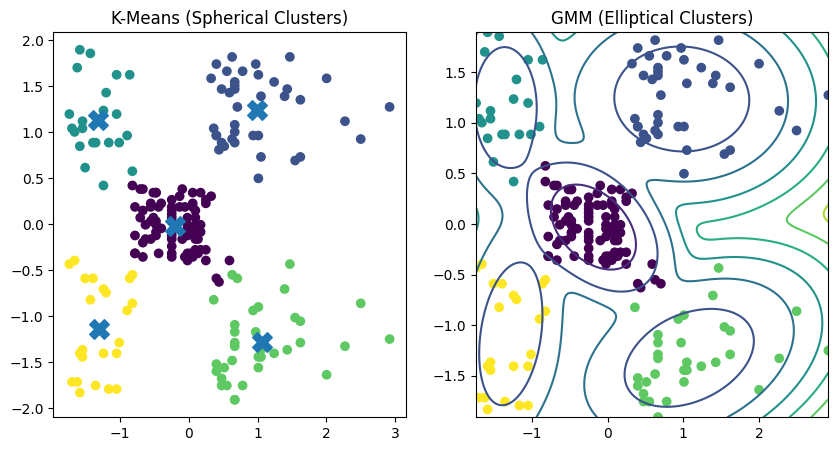


Cluster Means (GMM):
             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
1                     55.642857               49.369048
2                     86.538462               82.128205
3                     25.095238               80.047619
4                     88.818182               16.000000
5                     26.304348               20.913043

Sample Data:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   GMM_Cluster  Cluster_1_Prob  Cluster_2_Prob  Cluster_3_Prob  \
0            5    1.576897e-05    1.880092e-08    9.520312e-0

In [2]:
print("24BAD010-Anusri T")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"C:\Users\anusr\Downloads\Mall_Customers.csv")

if data.isnull().sum().any():
    data = data.dropna()

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

aic = []
bic = []
K_range = range(1, 11)

for k in K_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    gmm_temp.fit(X_scaled)
    aic.append(gmm_temp.aic(X_scaled))
    bic.append(gmm_temp.bic(X_scaled))

plt.figure()
plt.plot(K_range, aic, marker='o', label='AIC')
plt.plot(K_range, bic, marker='s', label='BIC')
plt.title("AIC & BIC for GMM")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.show()

optimal_k = 5

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm.fit(X_scaled)

probabilities = gmm.predict_proba(X_scaled)

clusters = np.argmax(probabilities, axis=1)
data['GMM_Cluster'] = clusters + 1

for i in range(optimal_k):
    data[f'Cluster_{i+1}_Prob'] = probabilities[:, i]

log_likelihood = gmm.score(X_scaled)
sil_score = silhouette_score(X_scaled, clusters)

print(f"\nLog-Likelihood: {log_likelihood}")
print(f"AIC: {gmm.aic(X_scaled)}")
print(f"BIC: {gmm.bic(X_scaled)}")
print(f"Silhouette Score: {sil_score}")

print("\nCluster Probability Distribution (first 5 rows):")
print(data[[f'Cluster_{i+1}_Prob' for i in range(optimal_k)]].head())

print("\nAverage Cluster Probabilities:")
print(data[[f'Cluster_{i+1}_Prob' for i in range(optimal_k)]].mean())

max_probs = probabilities.max(axis=1)

plt.figure()
plt.hist(max_probs, bins=5)
plt.title("GMM Confidence Distribution")
plt.xlabel("Confidence Level (0 to 1)")
plt.ylabel("Number of Customers")
plt.show()

print("\nAverage Confidence Level:", np.mean(max_probs))

plt.figure(figsize=(8,5))
for i in range(optimal_k):
    plt.hist(probabilities[:, i], bins=10, alpha=0.5, label=f'Cluster {i+1}')
plt.title("Cluster Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

plt.figure()
for i in range(1, optimal_k + 1):
    plt.scatter(
        X_scaled[data['GMM_Cluster'] == i, 0],
        X_scaled[data['GMM_Cluster'] == i, 1],
        label=f'Cluster {i}'
    )

x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 200)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 200)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.contour(X_grid, Y_grid, Z)
plt.title("GMM Clustering with Contours")
plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
plt.title("K-Means (Spherical Clusters)")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.contour(X_grid, Y_grid, Z)
plt.title("GMM (Elliptical Clusters)")
plt.show()

print("\nCluster Means (GMM):")
print(data.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

print("\nSample Data:")
print(data.head())